In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error
import os

img = Image.open('cat.jpg').convert('L') # Перевод в ЧБ (Вариант А)


img_array = np.array(img)
h, w = img_array.shape
original_shape = img_array.shape
original_flat = img_array.flatten()

Изображение успешно загружено и переведено в черно-белое. Теперь это матрица, где каждое значение - число от 0 до 255.

In [10]:
# Разложение матрицы на U, s, Vt (экономим память через full_matrices=False)
U, s, Vt = np.linalg.svd(img_array, full_matrices=False)

list_of_ranks = [1, 5, 10, 30, 100, min(h, w)]
approximations = []

# Восстановление для каждого ранга
for r in list_of_ranks:
    # Умножение без создания полной диагональной матрицы (работает быстрее)
    # U - h*r, s - r*1,  v - r*w    # U * s - h*r, u*s@v - h*w    approx = (U[:, :r] * s[:r]) @ Vt[:r, :]
    approximations.append(approx)

Матрица изображения разложена на три: $U$, $\Sigma$ (вектор $s$) и $V^T$. Мы восстановили изображение для разных рангов $r$, оставляя только $r$ самых больших сингулярных чисел. Чем больше $r$, тем больше деталей сохраняется.

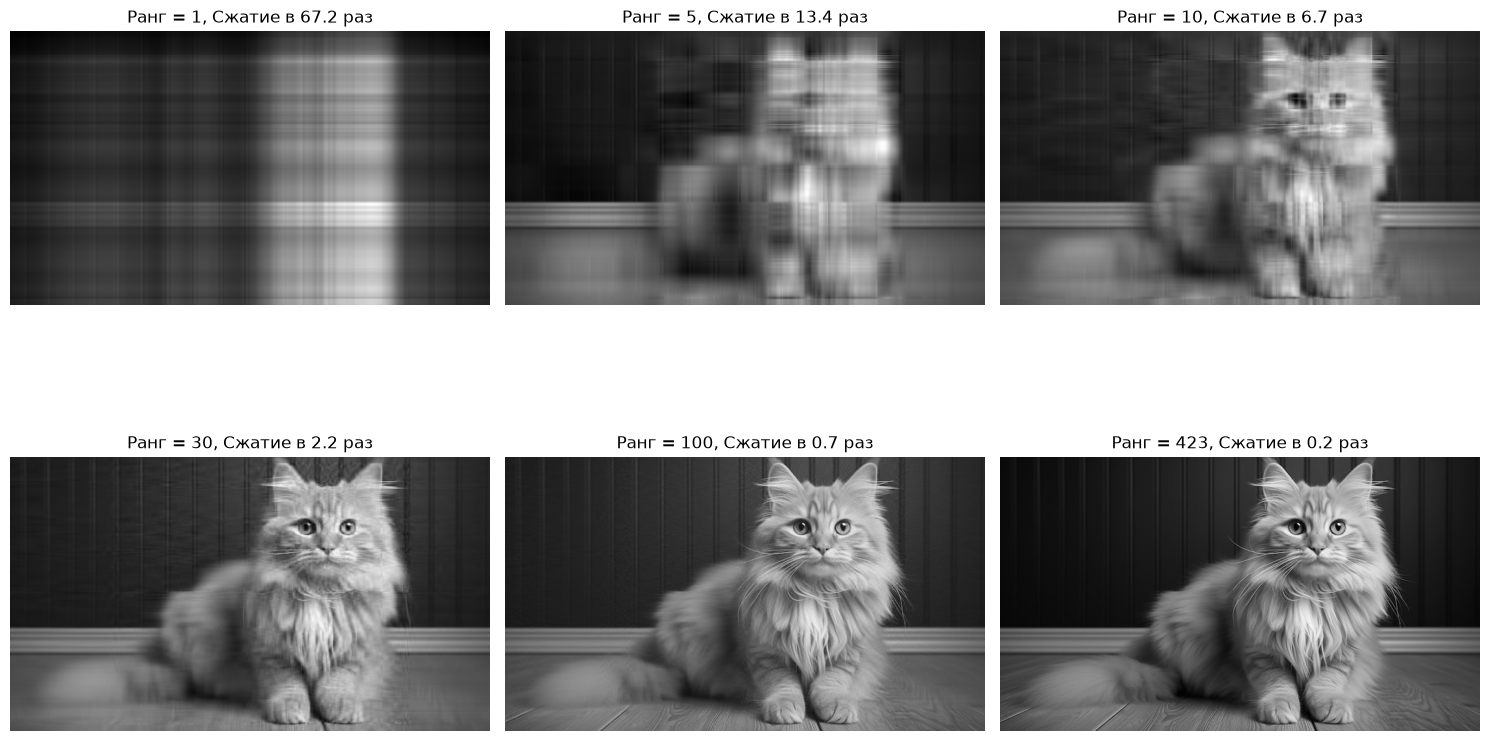

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Исходный размер в байтах (1 байт на пиксель для ЧБ)
original_size_bytes = h * w * 1 

for i, r in enumerate(list_of_ranks):
    # Размер сжатого: r * (h + 1 + w) чисел. float32 = 4 байта
    compressed_size_bytes = r * (h + 1 + w) * 4 
    compression_ratio = original_size_bytes / compressed_size_bytes
    
    axes[i].imshow(approximations[i], cmap='gray')
    axes[i].set_title(f"Ранг = {r}, Сжатие в {compression_ratio:.1f} раз")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

На графиках видно, что при малых рангах (1-5) видна только общая структура и контраст. Начиная с ранга 30, изображение становится визуально неотличимым от оригинала, при этом достигая существенного сжатия.

In [12]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка диапазона значений
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255)
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка монотонности MSE
mse_list = []
for i in range(len(approximations)):
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


1.  Визуально качество становится неотличимым от оригинала примерно при ранге 30
2. Для данного разрешения сжатие в 10 раз достигается при ранге 10-15
3. SVD лучше всего улавливает плавные градиенты и крупные однородные области (светлые/темные пятна). Мелкие детали, шум и резкие контрастные границы (текстуры) требуют высоких рангов, поэтому на них ошибка при низких $r$ максимальна.

# RGB

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error
import os

# Загружаем цветное изображение. Если файла нет, создаем тестовое (300x300x3)
img = Image.open('cat.jpg').convert('RGB')

# Переводим в float32 для корректных математических операций SVD
img_array = np.array(img, dtype=np.float32)
h, w, c = img_array.shape
original_shape = img_array.shape
original_flat = img_array.flatten()

# Исходный размер: 1 байт на канал (uint8)
original_size_bytes = h * w * c * 1 

In [15]:
list_of_ranks = [1, 5, 10, 30, 100, min(h, w)]
approximations = []

for r in list_of_ranks:
    reconstructed_channels = []
    for channel in range(c):
        # Разложение каждого канала отдельно
        U, s, Vt = np.linalg.svd(img_array[:, :, channel], full_matrices=False)
        # Быстрое восстановление через broadcasting (без создания diag-матрицы)
        approx_channel = (U[:, :r] * s[:r]) @ Vt[:r, :]
        reconstructed_channels.append(approx_channel)
    
    # Собираем каналы обратно в единое изображение (H x W x 3)
    approx_img = np.stack(reconstructed_channels, axis=-1)
    approximations.append(approx_img)


In [16]:
list_of_ranks = [1, 5, 10, 30, 100, min(h, w)]
approximations = []

for r in list_of_ranks:
    reconstructed_channels = []
    for channel in range(c):
        # Разложение каждого канала отдельно
        U, s, Vt = np.linalg.svd(img_array[:, :, channel], full_matrices=False)
        # Быстрое восстановление через broadcasting (без создания diag-матрицы)
        approx_channel = (U[:, :r] * s[:r]) @ Vt[:r, :]
        reconstructed_channels.append(approx_channel)
    
    # Собираем каналы обратно в единое изображение (H x W x 3)
    approx_img = np.stack(reconstructed_channels, axis=-1)
    approximations.append(approx_img)

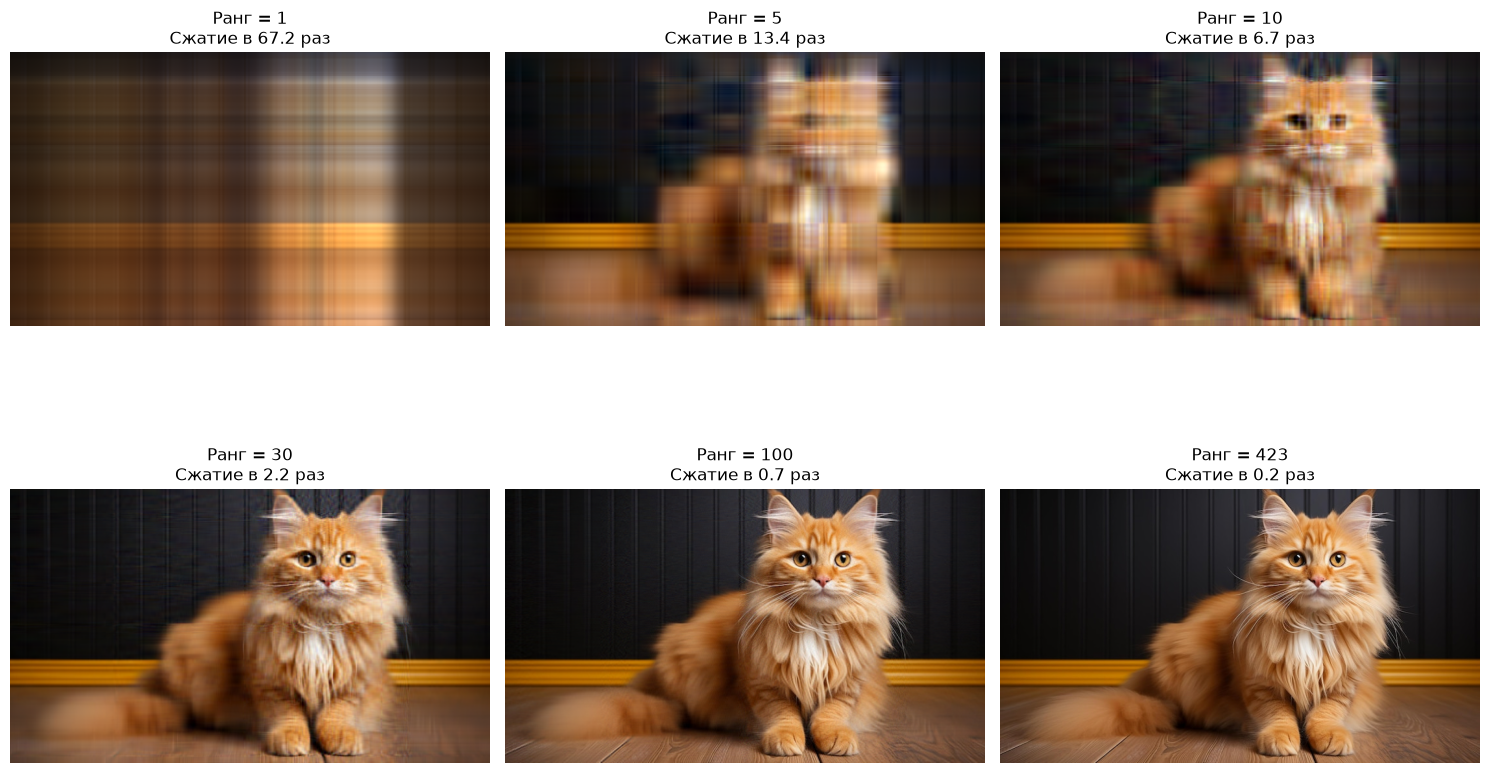

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, r in enumerate(list_of_ranks):
    # Размер сжатого: 3 канала * r * (h + 1 + w) чисел. float32 = 4 байта
    compressed_size_bytes = c * r * (h + 1 + w) * 4
    compression_ratio = original_size_bytes / compressed_size_bytes
    
    # Для корректного отображения ограничиваем диапазон [0, 255] и приводим к uint8
    display_img = np.clip(approximations[i], 0, 255).astype(np.uint8)
    
    axes[i].imshow(display_img)
    axes[i].set_title(f"Ранг = {r}\nСжатие в {compression_ratio:.1f} раз")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [18]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам (flatten() работает для 3D)
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!
